In [ ]:
!pip install torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 21.4 MB/s eta 0:00:00


# Load data

In [ ]:
from datasets import load_dataset, ClassLabel
from collections import Counter
# Example: A news dataset with images and text

dataset = load_dataset("ashraq/fashion-product-images-small", split="train", cache_dir='/kaggle/working/dataset_cache',streaming=False)
dataset = dataset.select_columns(["image", "productDisplayName", 'subCategory'])
dataset

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/867 [00:00<?, ?B/s]

data/train-00000-of-00002-6cff4c59f91661(…):   0%|          | 0.00/136M [00:00<?, ?B/s]

data/train-00001-of-00002-bb459e5ac5f01e(…):   0%|          | 0.00/135M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/44072 [00:00<?, ? examples/s]

Dataset({
    features: ['image', 'productDisplayName', 'subCategory'],
    num_rows: 44072
})

In [ ]:
for sample in dataset:
  if not (sample['image'] and sample['productDisplayName'] and sample['subCategory']): raise ValueError

In [ ]:
from collections import Counter
cls_counter = Counter(dataset["subCategory"])
print(len(cls_counter))
print(cls_counter)

45
Counter({'Topwear': 15383, 'Shoes': 7323, 'Bags': 3053, 'Bottomwear': 2685, 'Watches': 2542, 'Innerwear': 1806, 'Jewellery': 1079, 'Eyewear': 1073, 'Fragrance': 1001, 'Sandal': 961, 'Wallets': 925, 'Flip Flops': 913, 'Belts': 811, 'Socks': 698, 'Dress': 478, 'Loungewear and Nightwear': 464, 'Saree': 427, 'Lips': 425, 'Headwear': 293, 'Nails': 278, 'Makeup': 263, 'Ties': 258, 'Accessories': 129, 'Scarves': 118, 'Cufflinks': 108, 'Apparel Set': 106, 'Free Gifts': 104, 'Stoles': 90, 'Skin': 53, 'Skin Care': 49, 'Mufflers': 38, 'Eyes': 34, 'Sports Equipment': 21, 'Gloves': 20, 'Hair': 19, 'Bath and Body': 9, 'Water Bottle': 7, 'Perfumes': 6, 'Umbrellas': 6, 'Shoe Accessories': 4, 'Wristbands': 4, 'Beauty Accessories': 3, 'Sports Accessories': 3, 'Home Furnishing': 1, 'Vouchers': 1})


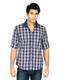

('Turtle Check Men Navy Blue Shirt', 'Topwear')


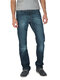

('Peter England Men Party Blue Jeans', 'Bottomwear')


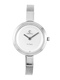

('Titan Women Silver Watch', 'Watches')


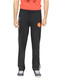

('Manchester United Men Solid Black Track Pants', 'Bottomwear')


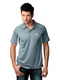

('Puma Men Grey T-shirt', 'Topwear')


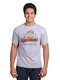

('Inkfruit Mens Chain Reaction T-shirt', 'Topwear')


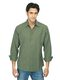

('Fabindia Men Striped Green Shirt', 'Topwear')


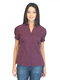

('Jealous 21 Women Purple Shirt', 'Topwear')


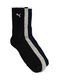

('Puma Men Pack of 3 Socks', 'Socks')


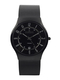

('Skagen Men Black Watch', 'Watches')


In [ ]:
# @title
from IPython.display import display
for i in range(10):
    display(dataset[i]['image'])
    print(f'{dataset[i]['productDisplayName'], dataset[i]['subCategory']}')

In [ ]:
# @title
dataset[:10]['image']

[<PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=60x80>,
 <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=60x80>,
 <PIL.Image.Image image mode=L size=60x80>,
 <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=60x80>,
 <PIL.Image.Image image mode=RGB size=60x80>,
 <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=60x80>,
 <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=60x80>,
 <PIL.Image.Image image mode=RGB size=60x80>,
 <PIL.Image.Image image mode=RGB size=60x80>,
 <PIL.Image.Image image mode=RGB size=60x80>]

In [ ]:
label = dataset.unique('subCategory')
label

['Topwear',
 'Bottomwear',
 'Watches',
 'Socks',
 'Shoes',
 'Belts',
 'Flip Flops',
 'Bags',
 'Innerwear',
 'Sandal',
 'Shoe Accessories',
 'Fragrance',
 'Jewellery',
 'Lips',
 'Saree',
 'Eyewear',
 'Scarves',
 'Dress',
 'Loungewear and Nightwear',
 'Wallets',
 'Apparel Set',
 'Headwear',
 'Mufflers',
 'Skin Care',
 'Makeup',
 'Free Gifts',
 'Ties',
 'Accessories',
 'Nails',
 'Beauty Accessories',
 'Water Bottle',
 'Skin',
 'Eyes',
 'Bath and Body',
 'Gloves',
 'Sports Accessories',
 'Cufflinks',
 'Sports Equipment',
 'Stoles',
 'Hair',
 'Perfumes',
 'Home Furnishing',
 'Umbrellas',
 'Wristbands',
 'Vouchers']

In [ ]:
ds = dataset.cast_column('subCategory', ClassLabel(names=dataset.unique('subCategory')))
ds = ds.rename_columns({
    "productDisplayName": "text",
    "subCategory": "label"
})
ds

Casting the dataset:   0%|          | 0/44072 [00:00<?, ? examples/s]

Dataset({
    features: ['image', 'text', 'label'],
    num_rows: 44072
})

In [ ]:
import torch
torch.manual_seed(42)
ds = ds.train_test_split(test_size=0.2)
train_ds = ds["train"]
test_ds = ds["test"]
len(train_ds), len(test_ds)

(35257, 8815)

In [ ]:
torch.manual_seed(42)
train_size = int(0.8*len(train_ds))
val_size = len(train_ds) - train_size
train_ds, val_ds = torch.utils.data.random_split(train_ds, [train_size, val_size])
print(len(train_ds), len(val_ds))

28205 7052


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [ ]:
from transformers import CLIPProcessor, CLIPVisionModelWithProjection, CLIPTextModelWithProjection #CLIPModel
import torch.nn as nn
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
class FCLIP(nn.Module):
    def __init__(self):
        super().__init__()
        # device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.vision_model = CLIPVisionModelWithProjection.from_pretrained("openai/clip-vit-base-patch32",output_attentions=True).to(device)
        self.text_model = CLIPTextModelWithProjection.from_pretrained("openai/clip-vit-base-patch32",output_attentions=True).to(device)
        self.processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")
        for param in self.parameters():
            param.requires_grad = False

    def collate_fn_image_text_label(self, batch):
        images = [item['image'] for item in batch]
        text = [item['text'] for item in batch]
        with torch.no_grad():
            image_inputs = self.processor(images=images, return_tensors="pt").to(device)
            text_inputs = self.processor(text=text, return_tensors="pt", padding=True).to(device)
            image_embeds = self.vision_model(**image_inputs).image_embeds
            text_embeds = self.text_model(**text_inputs).text_embeds
            X = torch.cat((image_embeds.unsqueeze(1), text_embeds.unsqueeze(1)), dim=1)
            y = torch.tensor([item['label'] for item in batch])
            return X, y

    def num_parameters(self):
        return self.vision_model.num_parameters() + self.text_model.num_parameters()


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

CLIPVisionModelWithProjection LOAD REPORT from: openai/clip-vit-base-patch32
Key                                                          | Status     |  | 
-------------------------------------------------------------+------------+--+-
text_model.encoder.layers.{0...11}.self_attn.k_proj.weight   | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.out_proj.bias   | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.k_proj.bias     | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.layer_norm1.weight        | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.q_proj.bias     | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.mlp.fc2.bias              | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.mlp.fc1.weight            | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.q_proj.weight   | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.mlp.fc1.bias              | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.layer_no

...

tokenizer_config.json:   0%|          | 0.00/592 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

In [ ]:
clip_model = FCLIP()
clip_model.num_parameters()

151277312

In [ ]:
torch.manual_seed(42)
train_loader = torch.utils.data.DataLoader(train_ds, batch_size=32, collate_fn=clip_model.collate_fn_image_text_label, shuffle=True)
val_loader = torch.utils.data.DataLoader(val_ds, batch_size=32, collate_fn=clip_model.collate_fn_image_text_label, shuffle=False)
test_loader = torch.utils.data.DataLoader(test_ds, batch_size=32, collate_fn=clip_model.collate_fn_image_text_label, shuffle=False)

# Helping function

In [ ]:
class EarlyStopping:
    def __init__(self, patience=5, min_delta=0.0):
        self.patience = patience
        self.min_delta = min_delta
        self.best_loss = float('inf')
        self.counter = 0

    def step(self, val_loss, model, optimizer, scheduler):
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.counter = 0
            torch.save({
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "scheduler_state_dict": scheduler.state_dict() if scheduler else None,
                "val_loss": self.best_loss
            }, f"checkpoint_{model.name}.pt")
            return False  # don't stop
        else:
            self.counter += 1

            return self.counter >= self.patience

    def reset(self):
        self.best_loss = float('inf')
        self.counter = 0

In [ ]:
from torchmetrics import Accuracy, F1Score
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
class TorchMetrics:
    def __init__(self, num_classes, acc=True, f1=True):
        self.metrics = {}
        if acc: self.metrics['accuracy'] = Accuracy(task="multiclass", num_classes=num_classes).to(device)
        if f1: self.metrics['f1'] = F1Score(task="multiclass", num_classes=num_classes, average='weighted').to(device)

    def update(self, preds, labels):
        for i in self.metrics: self.metrics[i].update(preds, labels)

    def compute(self):
        return {k: v.compute().item() for k, v in self.metrics.items()}

    def reset(self):
        for i in self.metrics: self.metrics[i].reset()

def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def load_model(checkpoint_path, model, optimizer=None, scheduler=None, early_stopping=None):
    checkpoint = torch.load(checkpoint_path)
    model.load_state_dict(checkpoint['model_state_dict'])
    if optimizer: optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    if scheduler: scheduler.load_state_dict(checkpoint['scheduler_state_dict'])
    if early_stopping: early_stopping.best_loss = checkpoint['val_loss']

def train_model(model, criterion, optimizer: torch.optim.Optimizer, train_loader, val_loader, scheduler=None, resume=False, num_epochs=50, seed=42):
    torch.manual_seed(seed)
    early_stopping = EarlyStopping(patience=5, min_delta=0.001)
    log_trainloss, log_valloss = [], []
    if resume:
        load_model(f"checkpoint_{model.name}.pt", model, optimizer, scheduler, early_stopping)
        for param_group in optimizer.param_groups: param_group['lr'] = 0.0001

    for epoch in range(num_epochs):
        model.train()
        train_loss = 0
        for x, y in train_loader:
            x ,y = x.to(device), y.to(device)
            optimizer.zero_grad()
            output = model(x)
            loss = criterion(output, y)
            loss.backward()
            train_loss += loss.item()
            optimizer.step()

        if scheduler: scheduler.step()

        model.eval()
        with torch.no_grad():
            val_loss = 0
            for x, y in val_loader:
                x, y = x.to(device), y.to(device)
                output = model(x)
                val_loss += criterion(output,y)
            val_loss /= len(val_loader)
            train_loss /= len(train_loader)
            log_trainloss.append(train_loss)
            log_valloss.append(val_loss)
            print(f"Epoch {epoch+1}: loss {train_loss}, val_loss {val_loss}")

            if early_stopping.step(val_loss, model, optimizer, scheduler):
                print("Early Stopping")
                break
    return log_trainloss, log_valloss

def evaluate_model(model, test_loader, torch_metrics):
    model.eval()
    with torch.no_grad():
        torch_metrics.reset()
        # correct = 0
        # total = 0
        for x, y in test_loader:
            x, y = x.to(device), y.to(device)
            output = model(x)
            predicted = output.argmax(dim=1)
            torch_metrics.update(predicted,y)
        #     total += y.size(0)
        #     correct += (predicted == y).sum().item()

        # print(total, correct)
        # print(f"Accuracy: {100 * correct / total}%")
        print(torch_metrics.compute())

def few_shot(label_embeds, test_loader, torch_metrics, model=None, test_nums=None):
    with torch.no_grad():
        torch_metrics.reset()
        # correct = 0
        # total = 0
        if not test_nums: test_nums = len(test_loader)
        for (x, y) in (test_loader):
            x, y = x.to(device), y.to(device)
            image_embed, text_embed = x.unbind(dim=1)
            if model: output = model(x)
            else: output = (image_embed + text_embed)/2
            predicted = (output @ label_embeds.T).argmax(dim=1)
            torch_metrics.update(predicted,y)
            # total += y.size(0)
            # correct += (predicted == y).sum().item()
            # if i > test_nums: break
        # print(total, correct)
        # print(f"Accuracy: {100 * correct / total}%")
        print(torch_metrics.compute())


In [ ]:
def embed_label(train_loader, num_class, default_projection_dim=512, model=None):
    with torch.no_grad():
        projection_dim = default_projection_dim if not model else model.projection_dim
        sum_embed = torch.zeros(num_class,projection_dim).to(device)
        count = torch.zeros(len(cls_counter), dtype=torch.long).to(device)
        for (X, y) in (train_loader):
            X, y = X.to(device), y.to(device)
            image_embed, text_embed = X.unbind(dim=1)
            if model: output = model(X)
            else: output = (image_embed + text_embed)/2
            sum_embed.index_add_(0, y, output)
            count.index_add_(0, y, torch.ones_like(y))
        return sum_embed / count.clamp(min=1).unsqueeze(-1)

# Apply static model to zero shot and few shot

We will use frozen CLIP model to classify.

## Zero shot with label embed by Clip from subCategory

In [ ]:
torch_metrics = TorchMetrics(num_classes=len(cls_counter))

In [ ]:
label_inputs = clip_model.processor(text=label, return_tensors="pt", padding=True).to(device)
label_embeds = clip_model.text_model(**label_inputs).text_embeds
label_embeds.shape

torch.Size([45, 512])

- Because no sample is provided to embed labels, this should be called zero-shot.
- However, it can still be "few" in a sense that the same text label from many samples would share same meaning in pretrained CLIP text's embedding space, if CLIP were to perform well.
- In other words, if CLIP is considered to be trained with a "few" examples in a training set, to recognize similar meaning of image and text, it may be said to perform few-shot from the training set to apply classification in test set.
- As "few" can be relative, similar definition for few-shot may be applied by the author.

In [ ]:
few_shot(label_embeds,test_loader,torch_metrics) # few-shot ~ zero-shot, relative to CLIP pretraining set.

{'accuracy': 0.615995466709137, 'f1': 0.6612886190414429}


## Few shot with label embeds from average of all samples' image and text embed

In [ ]:
few_shot(embed_label(train_loader,len(cls_counter)),test_loader,torch_metrics)

{'accuracy': 0.691321611404419, 'f1': 0.7401207685470581}


# Apply learned model to zero shot and few shot

In [ ]:
import torch.nn as nn
class Attention2(nn.Module):
    def __init__(self, embed_dim=512, nhead=8):
        super().__init__()
        self.nhead = nhead
        self.qkv = nn.Linear(embed_dim, embed_dim*3)
        self.proj = nn.Linear(embed_dim, embed_dim)
    def forward(self, x):
        B, N, D = x.shape
        head_dim = D//self.nhead
        qkv = self.qkv(x)
        qkv = qkv.reshape(B, N, 3, self.nhead, head_dim).permute(2, 0, 3, 1, 4)
        q, k, v = qkv[0], qkv[1], qkv[2]
        attn = (q @ k.transpose(-2, -1)) * (head_dim ** -0.5)
        attn = attn.softmax(dim=-1)
        x = attn @ v
        x = x.transpose(1, 2).reshape(B, N, D)
        x = self.proj(x)
        x = x / x.norm(dim=-1, keepdim=True) #(2)
        return x
    def forward_attn(self, x):
        B, N, D = x.shape
        head_dim = D//self.nhead
        qkv = self.qkv(x)
        qkv = qkv.reshape(B, N, 3, self.nhead, head_dim).permute(2, 0, 3, 1, 4)
        q, k, v = qkv[0], qkv[1], qkv[2]
        attn = (q @ k.transpose(-2, -1)) * (head_dim ** -0.5)
        attn = attn.softmax(dim=-1)
        return attn

class FreeTransformer2(nn.Module):
    def __init__(self, num_token=3, embed_dim=512, nhead=8, num_class=10):
        super().__init__()
        self.head = nn.Linear(embed_dim, num_class)
        self.n_token = nn.Parameter(torch.randn(1, num_token, embed_dim))
        self.attn = Attention2(embed_dim=embed_dim, nhead=nhead)
        self.name = "free_transformer"
        self.projection_dim = num_class
    def forward(self, x):
        B = x.shape[0]
        n_token = self.n_token.expand(B, -1, -1)
        num_token = n_token.shape[1]
        x = torch.cat((x, n_token), dim=1)
        x = self.attn(x)
        x = x[:, 0]
        x = self.head(x)
        # x = x / x.norm(dim=-1,keepdim=True) (!)
        return x
    def forward_attn(self, x):
        B = x.shape[0]
        n_token = self.n_token.expand(B, -1, -1)
        num_token = n_token.shape[1]
        x = torch.cat((x, n_token), dim=1)
        attn = self.attn.forward_attn(x)
        first_token_attn = attn[:, :, 0, :]
        return first_token_attn.mean(dim=1)


In [ ]:
from time import time
seed = 1775435470 #int(time())
print('seed:',seed)
torch.manual_seed(seed)

embed_dim = clip_model.vision_model.config.projection_dim

free_model = FreeTransformer2(num_token=1, embed_dim=embed_dim, nhead=8, num_class=len(cls_counter))
free_model = free_model.to(device)

optimizer = torch.optim.AdamW(free_model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=10
)
# try: load_model(f"checkpoint_{free_model.name}.pt", free_model, optimizer, scheduler)
# except: print("No checkpoint found")

print(free_model)
print(count_parameters(free_model))

seed: 1775435470
FreeTransformer2(
  (head): Linear(in_features=512, out_features=45, bias=True)
  (attn): Attention2(
    (qkv): Linear(in_features=512, out_features=1536, bias=True)
    (proj): Linear(in_features=512, out_features=512, bias=True)
  )
)
1074221


In [ ]:
seed: 1775358797, 1775435470

## Train

In [ ]:
# remove normalizing head (!)
log_trainloss, log_valloss = train_model(free_model, nn.CrossEntropyLoss(), optimizer, train_loader, val_loader, scheduler=scheduler, num_epochs=10)

Epoch 1: loss 0.6912520158985237, val_loss 0.15076377987861633
Epoch 2: loss 0.1020660184855972, val_loss 0.09210804104804993
Epoch 3: loss 0.0620638840417895, val_loss 0.06971453875303268
Epoch 4: loss 0.04541044475831717, val_loss 0.06445742398500443
Epoch 5: loss 0.03486491310834682, val_loss 0.059799548238515854
Epoch 6: loss 0.029158952141491074, val_loss 0.057783570140600204
Epoch 7: loss 0.022279595538853433, val_loss 0.050061196088790894
Epoch 8: loss 0.017708191778399936, val_loss 0.05077046528458595
Epoch 9: loss 0.014678119860226267, val_loss 0.05037644878029823
Epoch 10: loss 0.012925738715587814, val_loss 0.05003775283694267


Training time: ~29min

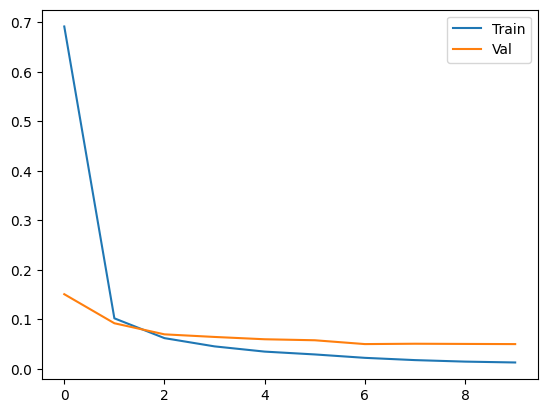

In [ ]:
import matplotlib.pyplot as plt

# Convert log_valloss to a list of CPU numbers
log_valloss_cpu = [loss.cpu().item() for loss in log_valloss]

plt.plot(log_trainloss, label='Train')
plt.plot(log_valloss_cpu, label='Val')
plt.legend()
plt.show()

## Test

In [ ]:
evaluate_model(free_model,test_loader,torch_metrics)

{'accuracy': 0.9908111095428467, 'f1': 0.9897392988204956}


Inference time: ~40s

In [ ]:
few_shot(embed_label(train_loader,len(cls_counter),model=free_model),test_loader,torch_metrics,model=free_model)

{'accuracy': 0.9804878234863281, 'f1': 0.9799184203147888}


Few shot of full training and test set inference time: ~3min

# Interpret model

In [ ]:
import random
def clip_image_attn(clip_model,sample):
    image_inputs = clip_model.processor(images=sample['image'], return_tensors="pt").to(device)
    image_output = clip_model.vision_model(**image_inputs,output_attentions=True)
    last_layer_attn = image_output.attentions[-1]

    cls_attn = last_layer_attn[:, :, 0, 1:] # [batch, nheads, seq_len]
    avg_cls_attn = cls_attn.mean(dim=1) # [batch, seq_len]
    return avg_cls_attn

def clip_text_attn(clip_model,sample):
    text_inputs = clip_model.processor(text=sample['text'], return_tensors="pt", padding=True).to(device)
    text_output = clip_model.text_model(**text_inputs, output_attentions=True)
    last_layer_attn = text_output.attentions[-1]

    first_eos_idx = text_inputs['attention_mask'].sum(dim=1)-1
    # or use:
    # eos_token_id = clip_model.processor.tokenizer.eos_token_id
    # first_eos_idx = (text_inputs["input_ids"] == eos_token_id).int().argmax(dim=1)

    # Attention from the EOS token to all other tokens
    eos_attn = last_layer_attn[torch.arange(last_layer_attn.size(0)), :, first_eos_idx, :]  # [batch, nheads, seq_len]
    return eos_attn.mean(dim=1)

def free_model_attn(free_model,clip_model,sample):
    sample = [{'image':img, 'text':txt, 'label':lbl} for img, txt, lbl in zip(sample['image'], sample['text'], sample['label'])]
    X, _ = clip_model.collate_fn_image_text_label(sample)
    return free_model.forward_attn(X)

ridx = random.randint(0,len(test_ds)-10)
samples = test_ds[ridx : ridx+10]

with torch.no_grad():
  image_attn, free_attn, text_attn = clip_image_attn(clip_model,samples), free_model_attn(free_model,clip_model,samples), clip_text_attn(clip_model,samples)
  patch_importance = free_attn[:,0].unsqueeze(1) * image_attn
  word_importance = free_attn[:,1].unsqueeze(1) * text_attn
patch_importance.shape, word_importance.shape

(torch.Size([10, 49]), torch.Size([10, 14]))

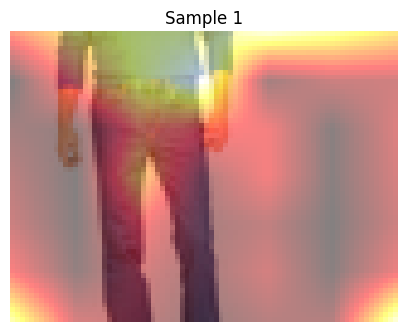

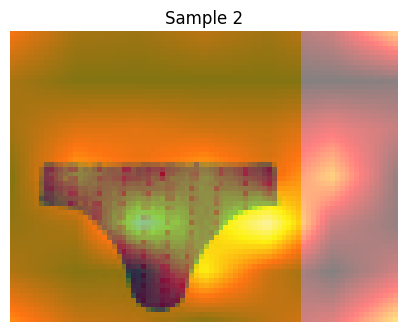

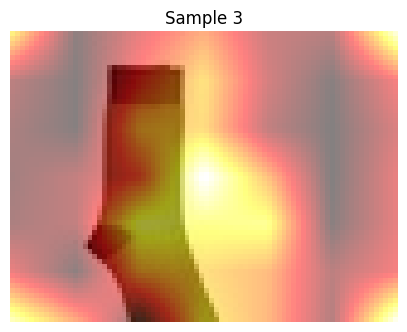

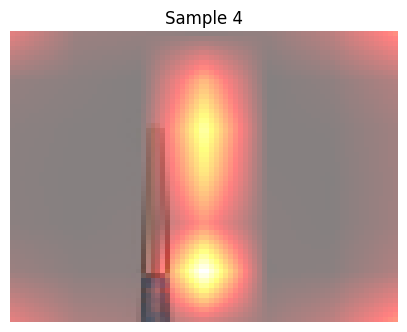

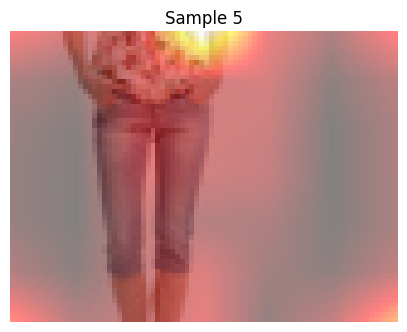

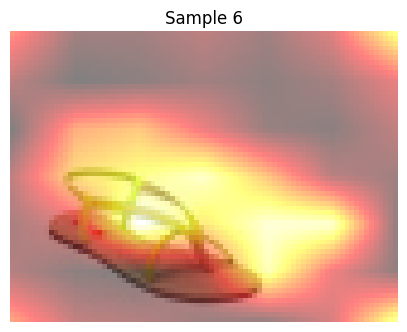

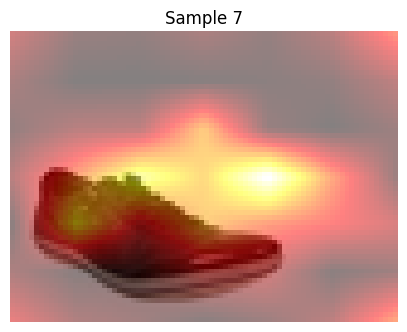

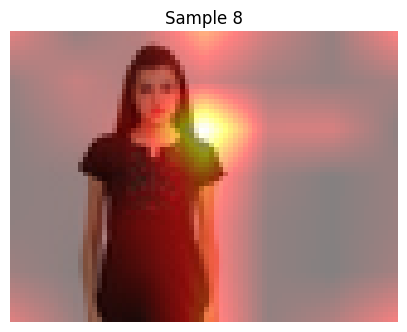

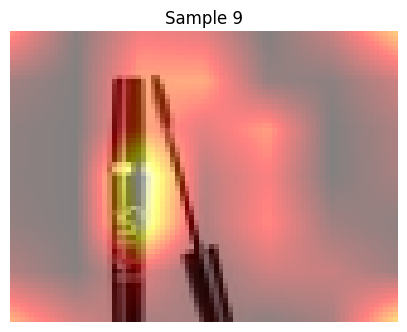

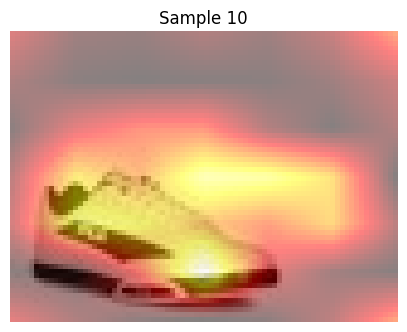

In [ ]:
import numpy as np
from scipy.ndimage import zoom

def plot_heatmap(images, patch_importance, h=60, w=80):
    heatmap = patch_importance.reshape(10, 7, 7).cpu().numpy()
    # Normalise for display
    heatmap = (heatmap - heatmap.min()) / (heatmap.max() - heatmap.min() + 1e-8)
    heatmap_resized_batch = zoom(heatmap, (1, h/7, w/7), order=1)

    for i in range(len(images)):
        plt.figure(figsize=(5, 5))
        plt.imshow(images[i])
        plt.imshow(heatmap_resized_batch[i], cmap='hot', alpha=0.5)
        plt.axis('off')
        plt.title(f"Sample {i+1}")
        plt.show()
plot_heatmap(samples['image'], patch_importance)

In [ ]:
from IPython.display import display, HTML
def displayHtml_token(processor, text, word_importance):
    text_inputs = processor(text=text, return_tensors="pt", padding=True).to(device)
    tokens = processor.tokenizer.convert_ids_to_tokens(text_inputs["input_ids"][0])
    # Normalise per word
    word_importance = (word_importance - word_importance.min()) / (word_importance.max() - word_importance.min() + 1e-8)

    html = "<div style='font-size:14px;'>"
    for token, w in zip(tokens, word_importance):
        if token in [processor.tokenizer.cls_token, processor.tokenizer.sep_token, processor.tokenizer.pad_token]: continue  # skip special tokens

        color = int(255 * (1 - w))
        html += f"<span style='background-color: rgb(255,{color},{color});'>{token} </span>"
    html += "</div>"
    display(HTML(html))

def displayHtml_batchtoken(processor, batch_text, word_importance):
    for i in range(len(batch_text)):
        print(f'sample {i}: {batch_text[i]}')
        displayHtml_token(processor, batch_text[i], word_importance[i])

displayHtml_batchtoken(clip_model.processor, samples['text'], word_importance)

sample 0: Wrangler Men Blue Texas Jeans


sample 1: Playboy Men Printed Grey Brief


sample 2: Reid & Taylor Men Green Socks


sample 3: Colorbar Color Intense Blue Lagoon Liquid Eye Liner 007


sample 4: Spykar Women Blue Jeans


sample 5: HM Women Green Flats


sample 6: United Colors of Benetton Men Cloud 9 Black Casual Shoes


sample 7: Folklore Women Black Kurta


sample 8: Lotus Herbals Maxlash Botanical Mascara


sample 9: Fila Men's Elite White Black Shoe
